# Kirsch Visualizer — Near-Wellbore Stresses

Visualization tool for the **Kirsch solution** of stresses on the borehole
wall, built on GeomechPy's `NearWellboreStressesCalculation`.

Every stress output is plotted for QC: radial (σrr), tangential/hoop (σθθ),
axial (σzz) and shear (σtz) components, plus the maximum/minimum principal
stresses (σ₁, σ₂) and the tortuosity angle. **All stresses are in psi.**

## Setup & imports

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "Project":
    REPO_ROOT = REPO_ROOT.parent.parent
elif REPO_ROOT.name == "example":
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

import numpy as np

import plotly.graph_objects as go
from plotly.subplots import make_subplots
import os
import glob
import shutil
import plotly.io as pio


def _configure_plotly_renderer():
    """Embed a static PNG next to the interactive figure so plots show in
    every viewer (GitHub, nbviewer, JupyterLab, VS Code). Falls back to the
    interactive-only renderer when no Chrome/Chromium engine is available for
    static image export."""
    candidates = [os.environ.get("BROWSER_PATH")]
    candidates += [shutil.which(name) for name in
                   ("google-chrome", "google-chrome-stable", "chromium",
                    "chromium-browser", "chrome")]
    candidates += sorted(glob.glob("/opt/pw-browsers/chromium-*/chrome-linux/chrome"))
    for path in candidates:
        if path and os.path.exists(path):
            os.environ["BROWSER_PATH"] = path
            break
    try:
        import plotly.graph_objects as _go
        _go.Figure().to_image(format="png", width=200, height=200)
        pio.renderers.default = "plotly_mimetype+png"
    except Exception:
        pio.renderers.default = "plotly_mimetype+notebook_connected"


_configure_plotly_renderer()

from geomechpy.near_wellbore_stresses import NearWellboreStressesCalculation

print("Imports OK — repo root:", REPO_ROOT)
print("Plotly renderer:", pio.renderers.default)

Imports OK — repo root: /home/user/GeomechPy_smolrun
Plotly renderer: plotly_mimetype+png


## Input parameters (single depth)

Edit these to explore different stress regimes and well trajectories.

In [2]:
# Far-field stresses (psi)
SHMIN = 6500.0
SHMAX = 8500.0
SVERT = 10000.0
PORE_PRESSURE = 4500.0
MUD_PRESSURE = 5000.0

# Orientation
SHMAX_AZIMUTH = 30.0       # deg from geographic North
BOREHOLE_DEVIATION = 0.0   # 0 = vertical well
BOREHOLE_AZIMUTH = 0.0     # deg

# Rock property
POISSON_RATIO_STATIC = 0.25

# Circumferential sampling (deg relative to Top-of-Hole)
theta = np.linspace(0, 360, 361)

print(f"Stress regime check: Sv={SVERT}, SHmax={SHMAX}, Shmin={SHMIN}")

Stress regime check: Sv=10000.0, SHmax=8500.0, Shmin=6500.0


## Compute Kirsch borehole-wall stresses

In [3]:
wall = NearWellboreStressesCalculation.calculate_kirsch_borehole_wall_stresses(
    shmin=SHMIN,
    shmax=SHMAX,
    svert=SVERT,
    pore_pressure=PORE_PRESSURE,
    shmax_azimuth=SHMAX_AZIMUTH,
    mud_pressure=MUD_PRESSURE,
    theta=theta,
    poisson_ratio_static=POISSON_RATIO_STATIC,
    borehole_deviation=BOREHOLE_DEVIATION,
    borehole_azimuth=BOREHOLE_AZIMUTH,
)

principals = NearWellboreStressesCalculation.calculate_principal_stresses_analytical_boreholewall(
    sigma_boreholewall_rr=wall.sigma_boreholewall_rr,
    sigma_boreholewall_tt=wall.sigma_boreholewall_tt,
    sigma_boreholewall_zz=wall.sigma_boreholewall_zz,
    sigma_boreholewall_tz=wall.sigma_boreholewall_tz,
)

# All borehole-wall stress outputs (psi). sigma_rt and sigma_rz are identically
# zero at the wall by the Kirsch boundary conditions.
print("sigma_rr (psi):", round(wall.sigma_boreholewall_rr.min(), 1), "–", round(wall.sigma_boreholewall_rr.max(), 1))
print("sigma_tt (psi):", round(wall.sigma_boreholewall_tt.min(), 1), "–", round(wall.sigma_boreholewall_tt.max(), 1))
print("sigma_zz (psi):", round(wall.sigma_boreholewall_zz.min(), 1), "–", round(wall.sigma_boreholewall_zz.max(), 1))
print("sigma_tz (psi):", round(wall.sigma_boreholewall_tz.min(), 1), "–", round(wall.sigma_boreholewall_tz.max(), 1))
print("sigma_rt (psi):", round(wall.sigma_boreholewall_rt.min(), 1), "–", round(wall.sigma_boreholewall_rt.max(), 1))
print("sigma_rz (psi):", round(wall.sigma_boreholewall_rz.min(), 1), "–", round(wall.sigma_boreholewall_rz.max(), 1))
print("sigma_1  (psi):", round(principals.sigma_boreholewall_1.min(), 1), "–", round(principals.sigma_boreholewall_1.max(), 1))
print("sigma_2  (psi):", round(principals.sigma_boreholewall_2.min(), 1), "–", round(principals.sigma_boreholewall_2.max(), 1))

sigma_rr (psi): 500.0 – 500.0
sigma_tt (psi): 10500.0 – 18500.0
sigma_zz (psi): 9000.0 – 11000.0
sigma_tz (psi): 0.0 – 0.0
sigma_rt (psi): 0.0 – 0.0
sigma_rz (psi): 0.0 – 0.0
sigma_1  (psi): 10500.0 – 18500.0
sigma_2  (psi): 9000.0 – 11000.0


## Cartesian QC — stress vs azimuth (psi)

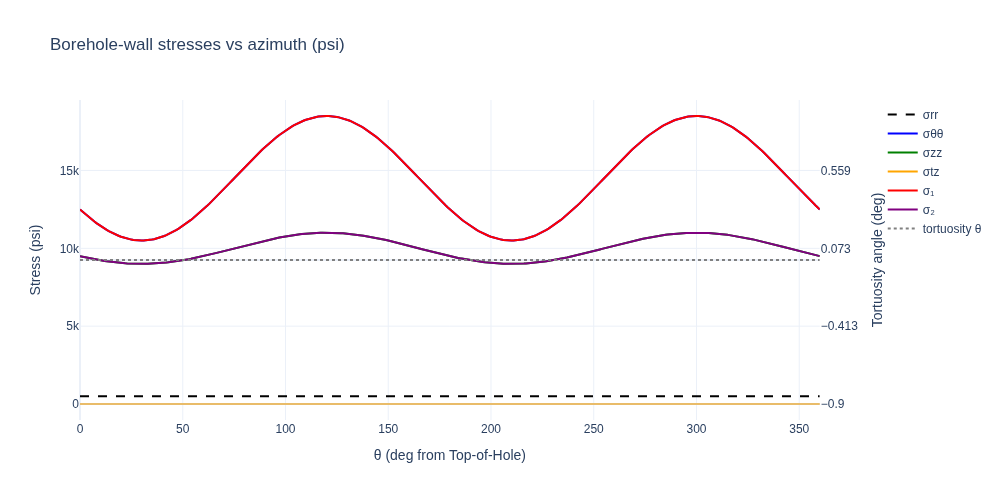

In [4]:
# Cartesian QC — all components vs azimuth (psi), plus tortuosity angle
fig = make_subplots(specs=[[{"secondary_y": True}]])
for name, series, color, dash in [
    ("σrr", wall.sigma_boreholewall_rr, "black", "dash"),
    ("σθθ", wall.sigma_boreholewall_tt, "blue", None),
    ("σzz", wall.sigma_boreholewall_zz, "green", None),
    ("σtz", wall.sigma_boreholewall_tz, "orange", None),
    ("σ₁", principals.sigma_boreholewall_1, "red", None),
    ("σ₂", principals.sigma_boreholewall_2, "purple", None),
]:
    fig.add_trace(go.Scatter(x=theta, y=series, mode="lines", name=name,
                             line=dict(color=color, dash=dash)),
                  secondary_y=False)

fig.add_trace(go.Scatter(x=theta, y=principals.theta_boreholewall_tortuosity, mode="lines",
                         name="tortuosity θ", line=dict(color="gray", dash="dot")),
              secondary_y=True)

fig.add_hline(y=0, line=dict(color="lightgray", width=1))
fig.update_xaxes(title="θ (deg from Top-of-Hole)", range=[0, 360])
fig.update_yaxes(title_text="Stress (psi)", secondary_y=False)
fig.update_yaxes(title_text="Tortuosity angle (deg)", secondary_y=True)
fig.update_layout(title="Borehole-wall stresses vs azimuth (psi)",
                  template="plotly_white", height=500, width=1000)
fig.show()

## Compare vertical vs horizontal well

Same far-field stresses; only borehole deviation changes.

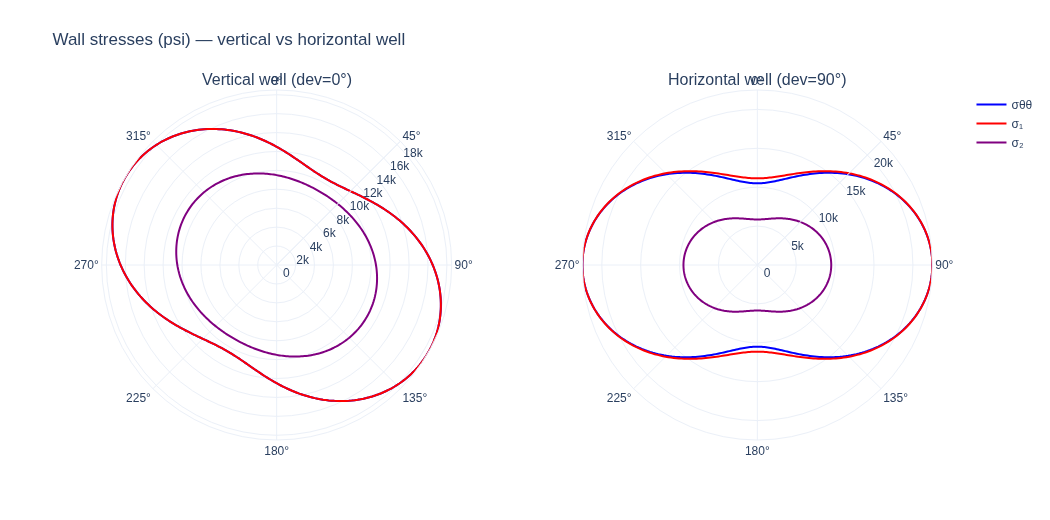

In [5]:
def run_kirsch(deviation):
    w = NearWellboreStressesCalculation.calculate_kirsch_borehole_wall_stresses(
        shmin=SHMIN, shmax=SHMAX, svert=SVERT,
        pore_pressure=PORE_PRESSURE, shmax_azimuth=SHMAX_AZIMUTH,
        mud_pressure=MUD_PRESSURE, theta=theta,
        poisson_ratio_static=POISSON_RATIO_STATIC,
        borehole_deviation=deviation, borehole_azimuth=BOREHOLE_AZIMUTH,
    )
    p = NearWellboreStressesCalculation.calculate_principal_stresses_analytical_boreholewall(
        sigma_boreholewall_rr=w.sigma_boreholewall_rr, sigma_boreholewall_tt=w.sigma_boreholewall_tt,
        sigma_boreholewall_zz=w.sigma_boreholewall_zz, sigma_boreholewall_tz=w.sigma_boreholewall_tz,
    )
    return w, p


wall_v, prin_v = run_kirsch(0.0)
wall_h, prin_h = run_kirsch(90.0)

fig = make_subplots(
    rows=1, cols=2, specs=[[{"type": "polar"}, {"type": "polar"}]],
    subplot_titles=("Vertical well (dev=0°)", "Horizontal well (dev=90°)"),
)


def add_pair(col, wall_, prin):
    show = col == 1
    fig.add_trace(go.Scatterpolar(r=wall_.sigma_boreholewall_tt, theta=theta, mode="lines",
                                  line=dict(color="blue", width=2),
                                  name="σθθ", showlegend=show), row=1, col=col)
    fig.add_trace(go.Scatterpolar(r=prin.sigma_boreholewall_1, theta=theta, mode="lines",
                                  line=dict(color="red", width=2),
                                  name="σ₁", showlegend=show), row=1, col=col)
    fig.add_trace(go.Scatterpolar(r=prin.sigma_boreholewall_2, theta=theta, mode="lines",
                                  line=dict(color="purple", width=2),
                                  name="σ₂", showlegend=show), row=1, col=col)


add_pair(1, wall_v, prin_v)
add_pair(2, wall_h, prin_h)

for i in (1, 2):
    key = "polar" if i == 1 else f"polar{i}"
    fig.update_layout(**{key: dict(
        angularaxis=dict(direction="clockwise", rotation=90),
        radialaxis=dict(angle=45, tickangle=45),
    )})

fig.update_layout(height=520, width=1050, template="plotly_white",
                  title="Wall stresses (psi) — vertical vs horizontal well",
                  margin=dict(t=90))
fig.show()

## Notes

- **$\theta = 0°$** is Top-of-Hole (TOH); angles increase clockwise.
- For a vertical well, breakouts form where $\sigma_{\theta\theta}$ is maximum (typically along Shmin).
- Tensile fractures initiate where $\sigma_{\theta\theta}$ is minimum (along SHmax).
- $\sigma_{rt}$ and $\sigma_{rz}$ are identically zero at the wall by the Kirsch boundary conditions.
- Change `BOREHOLE_DEVIATION`, `SHMAX_AZIMUTH` or `MUD_PRESSURE` above and re-run to explore the stress state.